# Begin

In [26]:
import os 
import sys 
import copy
from collections import namedtuple, defaultdict, Counter 
import itertools
import json
import datetime
import pprint
import re
import pickle
import dataclasses 
from dataclasses import dataclass 
import IPython
from enum import Flag, StrEnum, auto 
import sqlite3

from tqdm.notebook import tqdm
import numpy as np
import einops
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.utils.data

project_root_path = '${PROJECT_ROOT_PATH}' 
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

sys.path.append('.')
from subproject import *
sys.path.append(os.path.join(project_root_path, 'lib'))
from utils import * 
from logging_utils import *
from db_utils import *
from model_registry import *

# Setup

In [27]:
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    private_data_path=None,
    run_path='',
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/12_rnn',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/12_rnn',
 'run_path': '/home/misha/dev/mine/neurovision/run/12_rnn',
 'self_fname': '/home/misha/dev/mine/neurovision/12_rnn/prep_dataset.ipynb',
 'self_name': 'prep_dataset',
 'subproject_name': '12_rnn',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Types

In [28]:
class TokenLevel(StrEnum):
    SYMBOL = auto()
    WORD = auto()

# TextPreprocessor

In [29]:
class TextPreprocessor:
    def __init__(self, token_level):
        match token_level:
            case TokenLevel.SYMBOL:
                self.split_line = self.split_line_symbol
                self.check_token = self.check_token_symbol
            case TokenLevel.WORD:
                self.split_line = self.split_line_word
                self.check_token = self.check_token_word
            case _:
                assert False, f'Unsupported {token_level=}'
        
    def remove_pg_envelope(self, text):
        start_indx = text.find('START OF THIS PROJECT')
        start_indx = text.find('START OF THE PROJECT') if start_indx < 0 else start_indx
        end_indx = text.find('End of the Project Gutenberg')
        end_indx = text.find('END OF THE PROJECT GUTENBERG') if end_indx < 0 else end_indx
        assert start_indx >= 0
        assert end_indx >= 0
        
        while text[start_indx] != '\n': 
            start_indx += 1
        
        while text[start_indx] == '\n':
            start_indx += 1
        
        while text[end_indx] != '\n':
            end_indx -= 1

        return text[start_indx:end_indx]

    SPLIT_CHARS = r'"\',.:;?!()\[\]=\+\*/—%…\-\$£_&'
    SYMS_SUBST_TAB = {
        'ï': 'i', 'é': 'e', 'ô': 'o', 'î': 'i', 'ê': 'e', 'æ': 'e', 'ä': 'a', 'ç': 'c', 'ö': 'o', 'à': 'a', 'ü': 'u', 'è': 'e',
        'œ': 'e', 'ù': 'u', 'ò': 'o', 'ā': 'a', 'á': 'a', 'ñ': 'n', 'ó': 'o', 'ú': 'u', 'û': 'u', '✠': '', '†': 'd.', 'ë': 'e', 'ſ': 's', '•': '-', '°': '', chr(0x338): '',
        
    }
    
    def preprocess(self, text):
        text = re.sub(r'[“”]', '"', text)
        text = re.sub(r'[‘’]', "'", text)
        text = re.sub(r'\r\n', '\n', text)
        text = re.sub(r'([^\n])\n([^\n])', r'\1 \2', text)
        text = re.sub(r'\n(\n)+', '\n', text)
        text = re.sub(r'-(-)+', '. ', text)
        text = re.sub(r'\.\.\.', '…', text)
        text = text.lower()
        text = ''.join(map(lambda sym: TextPreprocessor.SYMS_SUBST_TAB.get(sym, sym), text))
        uniq_syms = Counter(text)
        unsupported_syms = list(filter(lambda sym: not re.match(r'[a-z0-9\s' + TextPreprocessor.SPLIT_CHARS + ']', sym), uniq_syms.keys()))
        assert not unsupported_syms, f'Unsupported syms={unsupported_syms}'
        return text

    
    def split_line_symbol(self, line):
        line = re.sub(r'\s(\s)+', ' ', line)
        return list(filter(self.check_token_symbol, line))
        
    def split_line_word(self, line):
        r = []

        # Combination of line.split() and re.split() is used to retain SPLIT_CHARS as individual tokens but to remove separators (\s)
        # Note: re.split with grouping is a must - in opposite case separators will get lost
        for x in line.split():
            r.extend(filter(None, re.split(r'([' + TextPreprocessor.SPLIT_CHARS + r'])', x))) # filter is used to remove empty elements

        return r

    def check_token_word(self, token):
        return re.match(r'[\w' + TextPreprocessor.SPLIT_CHARS +  r']+', token)

    def check_token_symbol(self, token):
        return re.match(r'[\w ' + TextPreprocessor.SPLIT_CHARS +  r']+', token)

In [30]:
x = "the dog's   bark ran towards him, stopped."
print('|' + '|'.join(TextPreprocessor(TokenLevel.WORD).split_line(x)) + '|')
print('|' + '|'.join(TextPreprocessor(TokenLevel.SYMBOL).split_line(x)) + '|')

|the|dog|'|s|bark|ran|towards|him|,|stopped|.|
|t|h|e| |d|o|g|'|s| |b|a|r|k| |r|a|n| |t|o|w|a|r|d|s| |h|i|m|,| |s|t|o|p|p|e|d|.|


# Configure

In [31]:
CHUNK_SIZE = 20
TOKEN_LEVEL = TokenLevel.WORD
BUNDLE_FNAME = os.path.join(CONFIG.private_data_path, f'bundle_{CHUNK_SIZE}_{TOKEN_LEVEL.value}.db')
SOURCES = [
    'crime_and_punishment',
    'the_great_gatsby',
    'the_mysterious_island',
    'the_picture_of_dorian_gray',
    'ulysses',
]

# Generate

In [32]:
with sqlite3.connect(BUNDLE_FNAME) as bundle_db_con:
    preprocessed_texts_dir_name = os.path.join(CONFIG.private_data_path, 'preprocessed')
    os.makedirs(preprocessed_texts_dir_name, exist_ok=True)
    
    source_to_text = {}
    source_to_tokens = {}
    df_sources = pd.DataFrame(dict(
        name=SOURCES,
        fname=list(map(lambda s: os.path.join(preprocessed_texts_dir_name, s + '.txt'), SOURCES)),
    ))
    df_sources.to_sql('sources', bundle_db_con, if_exists='replace')
    
    text_preprocessor = TextPreprocessor(TOKEN_LEVEL)
    
    for row in df_sources.itertuples():
        mr = ModelRegistry(maven_group_id='org.gutenberg')
        text = mr.get_asset_content(row.name, 1, 'txt').decode('utf-8')
        text = text_preprocessor.remove_pg_envelope(text)
        text = text_preprocessor.preprocess(text)
    
        with open(row.fname, 'w', encoding="utf-8") as f:
            f.write(text)
    
        source_to_text[row.name] = text

    drop_table_safe(bundle_db_con, 'chunks')
    vocab = Counter()
    
    for iter_no, iter_name in enumerate(('Vocab', 'Tokens', 'Chunks')):
        if iter_no in [0, 1]:
            for source_name, text in source_to_text.items():
                lines = text.splitlines()
                tokens = [] # for each line will contain list of tokens, i.e. list of lists
                
                for line_ind, line in tqdm(enumerate(lines), total=len(lines), desc=f'{iter_name}, {source_name}'):
                    line_tokens = text_preprocessor.split_line(line)
        
                    if iter_no == 0:
                        vocab.update(line_tokens)
                    else:
                        tokens.append(list(map(lambda t: vocab[t][0], line_tokens)))
                        
                source_to_tokens[source_name] = tokens
    
            if iter_no == 0:
                text_list, freq_list = zip(*vocab.most_common())
                ind_list = list(range(len(text_list)))
                vocab = dict(zip(text_list, zip(ind_list, freq_list))) # make dict: text -> (ind, freq)
        
        elif iter_no == 2:
            for source_name, tokens in source_to_tokens.items():
                chunks = []
                source_ind = df_sources[df_sources.name == source_name].index.item()
                line_inds = [] # aligned with tokens (1-to-1 mapping), stamps every token with a line index
    
                for line_ind, line_tokens in enumerate(tokens):
                    line_inds.extend([line_ind] * len(line_tokens))
    
                tokens = list(itertools.chain.from_iterable(tokens)) # flatten tokens list
                assert len(line_inds) == len(tokens)
                
                for start_ind in tqdm(range(len(tokens) - CHUNK_SIZE), desc=f'{iter_name}, {source_name}'):
                    chunk = tokens[start_ind:start_ind+CHUNK_SIZE]
                    assert len(chunk) == CHUNK_SIZE
                    # chunks.append((np.array(chunk), source_ind, line_inds[start_ind], line_inds[start_ind+CHUNK_SIZE-1]))
                    chunks.append((','.join(map(str, chunk)), source_ind, line_inds[start_ind], line_inds[start_ind+CHUNK_SIZE-1]))
    
                chunk_list, source_id_list, start_line_ind_list, end_line_ind_list = zip(*chunks)
                pd.DataFrame(dict(
                    chunk=chunk_list,
                    source_ind=source_id_list,
                    start_line_ind=start_line_ind_list,
                    end_line_ind=end_line_ind_list,
                )).to_sql('chunks', bundle_db_con, if_exists='append')
        else:
            assert False, (iter_no, iter_name)
    
    text_list, ind_freq_list = zip(*vocab.items())
    ind_list, freq_list = zip(*ind_freq_list)
    df_vocab = pd.DataFrame(dict(
        text=text_list,
        freq=freq_list,
    ), index=ind_list)
    df_vocab.to_sql('vocab', bundle_db_con, if_exists='replace')
    LOG(f'Bundle generated and saved to "{BUNDLE_FNAME}"')

Vocab, crime_and_punishment:   0%|          | 0/3970 [00:00<?, ?it/s]

Vocab, the_great_gatsby:   0%|          | 0/1653 [00:00<?, ?it/s]

Vocab, the_mysterious_island:   0%|          | 0/4905 [00:00<?, ?it/s]

Vocab, the_picture_of_dorian_gray:   0%|          | 0/1527 [00:00<?, ?it/s]

Vocab, ulysses:   0%|          | 0/7180 [00:00<?, ?it/s]

...

Chunks, the_great_gatsby:   0%|          | 0/61718 [00:00<?, ?it/s]

Chunks, the_mysterious_island:   0%|          | 0/233950 [00:00<?, ?it/s]

Chunks, the_picture_of_dorian_gray:   0%|          | 0/97500 [00:00<?, ?it/s]

Chunks, ulysses:   0%|          | 0/329246 [00:00<?, ?it/s]

Bundle generated and saved to "/home/misha/dev/mine/neurovision/data/12_rnn/bundle_20_word.db"


# Verify

## Load

In [33]:
%%time
with sqlite3.connect(BUNDLE_FNAME) as bundle_db_con:
    df_chunks = pd.read_sql('SELECT * FROM chunks', bundle_db_con)
    df_vocab = pd.read_sql('SELECT * FROM vocab', bundle_db_con)
    df_sources = pd.read_sql('SELECT * FROM sources', bundle_db_con)

CPU times: user 1.38 s, sys: 60 ms, total: 1.44 s
Wall time: 1.44 s


## Verify vocab

In [34]:
df_vocab.head()

,index,text,freq
0,0,",",58534
1,1,.,50302
2,2,the,45958
3,3,and,23147
4,4,of,21958


In [35]:
df_vocab.tail()

,index,text,freq
36171,36171,figtrees,1
36172,36172,rosegardens,1
36173,36173,zurich,1
36174,36174,1914,1
36175,36175,1921,1


## Verify chunks

In [36]:
columns = defaultdict(list)
chunks_to_show = 10
chunk_inds = RNG.choice(len(df_chunks), 10, replace=False)
df_inspect = df_chunks.loc[chunk_inds]
df_inspect = pd.merge(df_inspect, df_sources, left_on='source_ind', right_index=True, how='left')
df_inspect.rename(columns={'name': 'source_name', 'fname': 'source_fname'}, inplace=True)
df_inspect['chunk1'] = df_inspect['chunk'].map(lambda c: list(map(lambda t: df_vocab.iloc[int(t)].text, c.split(','))))

sources = {}

for row in df_inspect.itertuples():
    print(f'Chunk #{row.Index}, source={row.source_name} (#{row.source_ind}), lines={row.start_line_ind}:{row.end_line_ind}')
    print('- as int list: |' + '|'.join(row.chunk.split(',')) + '|')
    print('- as str list: |' + '|'.join(map(str, row.chunk1)) + '|')
    
    if not row.source_name in sources:
        with open(row.source_fname, 'r', encoding='utf-8') as f:
            sources[row.source_name] = f.readlines()
        
    print('- origin:      ' + ''.join(sources[row.source_name][row.start_line_ind:row.end_line_ind+1]))
    print()

Chunk #578004, source=the_picture_of_dorian_gray (#3), lines=428:429
- as int list: |2365|1|5|226|296|693|1|5|235|59|86|1516|4|1024|144|39|33|665|195|341|
- as str list: |advice|.|"|lord|henry|smiled|.|"|people|are|very|fond|of|giving|away|what|they|need|most|themselves|
- origin:      "dear basil! i have not laid eyes on him for a week. it is rather horrid of me, as he has sent me my portrait in the most wonderful frame, specially designed by himself, and, though i am a little jealous of the picture for being a whole month younger than i am, i must admit that i delight in it. perhaps you had better write to him. i don't want to see him alone. he says things that annoy me. he gives me good advice."
lord henry smiled. "people are very fond of giving away what they need most themselves. it is what i call the depth of generosity."


Chunk #447325, source=the_mysterious_island (#2), lines=2522:2522
- as int list: |23|220|18|35|159|1353|0|40|55|53|527|32|231|2|328|105|0|564|60|9|
- as str l

In [37]:
len(df_chunks)

980123

# ChunkDataset

In [38]:
# class ChunkDataset(torch.utils.data.IterableDataset):
#     def __init__(self, db_fname, prefetch_buffer_size=100, rng=None):
#         super().__init__()
#         self.db_con = sqlite3.connect(db_fname)
#         self.min_row_id, self.max_row_id = self.db_con.execute('SELECT min(rowid), max(rowid) FROM chunks').fetchone()
#         self.rows_count = self.max_row_id - self.min_row_id + 1
#         assert self.rows_count == self.db_con.execute('SELECT count(rowid) FROM chunks').fetchone()[0], (self.rows_count, self.min_row_id, self.max_row_id)
#         self.row_ids = []
#         self.row_ids_ind = -1
#         self.prefetch_buffer_size = prefetch_buffer_size
#         self.prefetch_buffer = None
#         self.rng = np.random.default_rng() if rng is None else rng

#     def __len__(self):
#         return self.rows_count
        
#     def __iter__(self):
#         self.row_ids = self.min_row_id + self.rng.choice(self.rows_count, size=self.rows_count, replace=False, shuffle=False)
#         assert len(self.row_ids) == self.rows_count
#         self.row_ids_ind = 0
#         self._prefetch()
#         return self

#     def __next__(self):
#         try:
#             return next(self.prefetch_buffer)
#         except StopIteration:
#             self._prefetch()
#             return next(self.prefetch_buffer)

#     def _prefetch(self):
#         fetch_row_ids = self.row_ids[self.row_ids_ind:self.row_ids_ind+self.prefetch_buffer_size]

#         if len(fetch_row_ids) == 0:
#             raise StopIteration()
            
#         self.row_ids_ind += len(fetch_row_ids)
#         query = 'SELECT chunk FROM chunks WHERE rowid IN (' + ','.join('?' * len(fetch_row_ids)) + ')'
#         rows = self.db_con.execute(query, list(map(int, fetch_row_ids))).fetchall()
#         rows = np.array(list(map(lambda row: np.fromstring(row[0], dtype=int, sep=','), rows)))
#         rows = torch.tensor(rows)
#         assert len(rows) == len(fetch_row_ids), (len(rows), len(fetch_row_ids))
#         self.prefetch_buffer = iter(rows)

In [39]:
def create_dataset(prefetch_buffer_size):
    return ChunkDataset(BUNDLE_FNAME, prefetch_buffer_size, RNG)

In [49]:
ds = create_dataset(100)
print(next(iter(ds)))
print(next(iter(ds)))

tensor([    2,   206,   692,     7,   852,   509, 11458,  2601,    28,     0,
          354,     6,   449,    23,     7,   179,     3,  1542,  2358,    39])
tensor([   9,    1,   34,  239,    6,   32,  379,    9,  157,    0, 1709,    3,
         692,  138,    1,    2,  182,   14,  593,    0])


In [50]:
ds = create_dataset(100)
limit = min(len(ds), 1_000_000)

for x in tqdm(zip(ds, range(limit)), total=limit):
    pass

  0%|          | 0/980123 [00:00<?, ?it/s]

In [51]:
ds = create_dataset(10)
dl = torch.utils.data.DataLoader(ds, batch_size=100)
limit = min(len(ds), 1_000_000) // dl.batch_size

for x, _ in tqdm(zip(dl, range(limit)), total=limit):
    pass

  0%|          | 0/9801 [00:00<?, ?it/s]

In [43]:
batch_sizes = list(range(10, 100 + 10, 10))
prefetch_buffer_sizes = range(10, 100 + 10, 10)
durations = []

for batch_size in tqdm(batch_sizes):
    durations_for_batch_size = []
    
    for prefetch_buffer_size in tqdm(prefetch_buffer_sizes, leave=False):
        ds = create_dataset(prefetch_buffer_size)
        dl = torch.utils.data.DataLoader(ds, batch_size=batch_size)
        t0 = time.time()
        limit = min(len(ds), 100_000)
        
        for x, _ in zip(dl, range(limit // batch_size)):
            pass

        t1 = time.time()
        dur = t1 - t0
        assert dur > 0
        durations_for_batch_size.append(dur)    
    
    durations.append(durations_for_batch_size)        

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

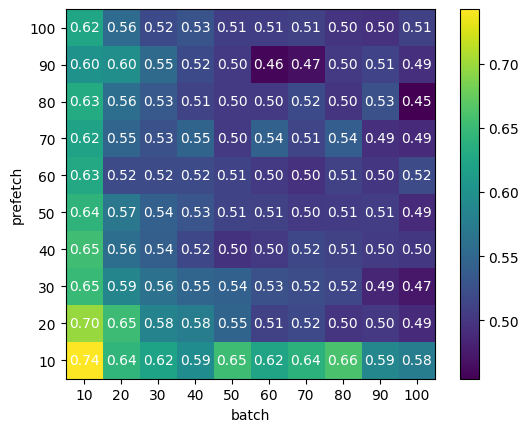

In [44]:
fig, ax = plt.subplots()
im = ax.imshow(durations, origin='lower');
ax.set_xticks(range(len(batch_sizes)), labels=list(map(str, batch_sizes)))#, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(prefetch_buffer_sizes)), labels=list(map(str, prefetch_buffer_sizes)))#, rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel('batch')
ax.set_ylabel('prefetch')

for i in range(len(batch_sizes)):
    for j in range(len(prefetch_buffer_sizes)):
        text = ax.text(j, i, f'{durations[i][j]:.2f}', ha="center", va="center", color="w")

fig.colorbar(im, ax=ax);

In [45]:
# s = []

# for i in range(10):
#     s.append((','.join(map(str, range(i, i+40))),))

# s

In [46]:
# %%timeit
# np.array(list(map(lambda row: list(map(int, row[0].split(','))), s)))

In [47]:
# %%timeit
# np.array(list(map(lambda row: np.fromstring(row[0], dtype=int, sep=','), s)))